In [38]:
import torch
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("torch built cuda:", torch.version.cuda)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

cuda available: True
torch cuda version: 12.1
torch built cuda: 12.1
Using device: cuda


In [52]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.interpolate import griddata
from datetime import datetime

# 중요도 판별
import eli5 
from eli5.sklearn import PermutationImportance 
from xgboost import XGBClassifier
from xgboost import plot_importance

# PyTorch 관련 import
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print(torch.cuda.is_available())

True


In [53]:
train_val = pd.read_csv("train.csv")
test_X = pd.read_csv("test.csv")

display(train_val.head())
display(test_X.head())

,Mass_Pilot,Width,Aspect,Inch,Plant,Proc_Param1,Proc_Param2,Proc_Param3,Proc_Param4,Proc_Param5,...,p247,p248,p249,p250,p251,p252,p253,p254,p255,Class
0,False,245,40,19,Plant_6,465.00,631.85,1460.8,1985,2059,...,1.475031,1.473817,1.472950,1.474981,1.477011,1.479157,1.483289,1.487421,1.491552,Good
1,False,275,40,21,Plant_2,516.01,701.87,1621.1,2205,2291,...,1.320114,1.326607,1.333636,1.340665,1.347694,1.352602,1.355859,1.359115,1.362371,Good
2,False,225,45,17,Plant_7,416.99,583.14,1310.0,1832,1918,...,1.344303,1.346259,1.348215,1.350183,1.352166,1.354149,1.356112,1.358066,1.360021,Good
3,True,275,30,20,Plant_7,490.01,623.89,1539.4,1960,2040,...,1.389538,1.389953,1.393673,1.397393,1.401113,1.405803,1.411120,1.416437,1.421754,Good
4,True,265,45,21,Plant_2,516.01,714.61,1621.1,2245,2336,...,1.435297,1.431648,1.428000,1.424352,1.420704,1.417607,1.415256,1.412904,1.410553,Good


,ID,Mass_Pilot,Width,Aspect,Inch,Plant,Proc_Param1,Proc_Param2,Proc_Param3,Proc_Param4,...,p246,p247,p248,p249,p250,p251,p252,p253,p254,p255
0,ID_0,True,235,60,18,Plant_2,442.01,687.55,1388.6,2160,...,1.169287,1.166026,1.166735,1.168156,1.170798,1.172955,1.173441,1.173989,1.175112,1.176234
1,ID_1,False,245,40,19,Plant_2,464.99,631.85,1460.8,1985,...,1.615543,1.628728,1.643133,1.657539,1.654435,1.647163,1.639891,1.637400,1.635183,1.632966
2,ID_2,False,235,40,19,Plant_2,464.99,619.43,1460.8,1946,...,1.453175,1.451461,1.448824,1.446188,1.435310,1.423030,1.410750,1.367765,1.321797,1.275830
3,ID_3,True,245,45,19,Plant_2,464.99,646.17,1460.8,2030,...,1.234581,1.238925,1.248509,1.260011,1.271885,1.286289,1.300693,1.306279,1.304755,1.303231
4,ID_4,True,255,55,19,Plant_2,464.99,708.24,1460.8,2225,...,1.346540,1.348108,1.349677,1.352246,1.355194,1.358359,1.361780,1.364867,1.366732,1.368597


In [54]:
train_X = train_val.drop(columns=['Class'])
train_Y = train_val['Class'].apply(lambda x: 1 if x == 'NG' else 0)

cat_list = train_X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
num_list = sorted(list(set(train_X.columns) - set(cat_list)))

print(f"범주형 변수 개수: {len(cat_list)}")
print(f"수치형 변수 개수: {len(num_list)}")

test_ID = test_X['ID']
test_X = test_X.drop(columns=['ID'])

print(f"test_X shape: {test_X.shape}")
print(f"test_ID shape: {test_ID.shape}")

범주형 변수 개수: 3
수치형 변수 개수: 795
test_X shape: (466, 798)
test_ID shape: (466,)


Basic data 전처리

In [55]:
OE = OneHotEncoder(min_frequency=0.01, handle_unknown='infrequent_if_exist', sparse_output=False)
OE.fit(train_X[cat_list])
onehot_cols = OE.get_feature_names_out(cat_list)

# train 데이터 원핫인코딩
after_onehot = pd.DataFrame(OE.transform(train_X[cat_list]), columns=onehot_cols, index=train_X.index)
train_X = pd.concat([after_onehot, train_X[num_list]], axis=1)
# test 데이터 원핫인코딩
after_onehot = pd.DataFrame(OE.transform(test_X[cat_list]), columns=onehot_cols, index=test_X.index)
test_X = pd.concat([after_onehot, test_X[num_list]], axis=1)
#data split
train_X, val_X, train_Y, val_Y = train_test_split(train_X, train_Y, test_size=0.2, random_state=42)

3차 보간법을 사용한 그리드 생성 후 (x,y,p) 재구성

In [56]:
x_cols = [f'x{i}' for i in range(256)]
y_cols = [f'y{i}' for i in range(256)]
p_cols = [f'p{i}' for i in range(256)]

all_data = pd.concat([train_val, test_X], ignore_index=True)
x_values = all_data[x_cols].values.flatten()
y_values = all_data[y_cols].values.flatten()

x_values = x_values[~np.isnan(x_values)]
y_values = y_values[~np.isnan(y_values)]

x_min = x_values.min()
x_max = x_values.max()
y_min = y_values.min()
y_max = y_values.max()

print(f"📊 좌표 범위 분석 결과:")
print(f"   X 좌표 범위: {x_min:.2f} ~ {x_max:.2f}")
print(f"   Y 좌표 범위: {y_min:.2f} ~ {y_max:.2f}")

📊 좌표 범위 분석 결과:
   X 좌표 범위: 160.58 ~ 425.61
   Y 좌표 범위: 40.52 ~ 185.62


In [57]:
class SpatialRasterizer:
    def __init__(self, x_min, x_max, y_min, y_max, grid_size=64, interpolation_method='linear'):
        """
        Args:
            x_min, x_max, y_min, y_max: 좌표 범위
            grid_size: 그리드 크기 (기본값: 64)
            interpolation_method: 보간 방법 ('linear' 또는 'cubic', 기본값: 'cubic')
        """
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max
        self.grid_size = grid_size
        self.interpolation_method = interpolation_method
        self.x_range = x_max - x_min if x_max > x_min else 1
        self.y_range = y_max - y_min if y_max > y_min else 1

        print(f"📐 SpatialRasterizer 초기화:")
        print(f"   - 그리드 크기: {grid_size}x{grid_size}")
        print(f"   - 보간 방법: {interpolation_method}")

    def rasterize_with_real_coordinates(self, data_row, method=None):
        """
        선형/3차 보간법을 사용한 그리드 생성

        Args:
            data_row: 데이터 행 (Pandas Series)
            method: 보간 방법 ('linear' 또는 'cubic', None이면 self.interpolation_method 사용)

        Returns:
            grid: (grid_size, grid_size) 형태의 보간된 그리드
        """
        if method is None:
            method = self.interpolation_method

        x_cols = [f'x{i}' for i in range(256)]
        y_cols = [f'y{i}' for i in range(256)]
        p_cols = [f'p{i}' for i in range(256)]

        # pandas Series를 numpy array로 명시적 변환 (NaN 처리 포함)
        x_coords = pd.to_numeric(data_row[x_cols], errors='coerce').values
        y_coords = pd.to_numeric(data_row[y_cols], errors='coerce').values
        p_values = pd.to_numeric(data_row[p_cols], errors='coerce').values

        # numpy array로 명시적 변환
        x_coords = np.array(x_coords, dtype=np.float64)
        y_coords = np.array(y_coords, dtype=np.float64)
        p_values = np.array(p_values, dtype=np.float64)

        # 유효한 점들만 추출 (NaN이 아닌 점들)
        valid_mask = ~(np.isnan(x_coords) | np.isnan(y_coords) | np.isnan(p_values))

        if valid_mask.sum() < 3:  # 보간을 위해 최소 3개 점 필요
            # 점이 너무 적으면 0으로 채운 그리드 반환
            return np.zeros((self.grid_size, self.grid_size), dtype=np.float32)

        # 유효한 점들의 좌표와 값
        valid_x = x_coords[valid_mask]
        valid_y = y_coords[valid_mask]
        valid_p = p_values[valid_mask]

        # 그리드 포인트 생성 (정규화된 좌표)
        x_grid = np.linspace(self.x_min, self.x_max, self.grid_size)
        y_grid = np.linspace(self.y_min, self.y_max, self.grid_size)
        X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

        # 보간 수행
        # griddata는 (N,) 형태의 1D 배열을 받으므로 flatten
        grid_points = np.column_stack([X_grid.flatten(), Y_grid.flatten()])
        data_points = np.column_stack([valid_x, valid_y])

        # scipy.interpolate.griddata를 사용한 보간
        # method: 'linear' (선형 보간) 또는 'cubic' (3차 보간)
        interpolated_values = griddata(
            data_points,           # 입력 점들의 좌표 (N, 2)
            valid_p,               # 입력 점들의 값 (N,)
            grid_points,           # 보간할 그리드 포인트들 (M, 2)
            method=method,         # 'linear' 또는 'cubic'
            fill_value=0.0         # 보간 불가능한 영역의 기본값
        )

        # 그리드 형태로 재구성
        grid = interpolated_values.reshape(self.grid_size, self.grid_size).astype(np.float32)

        return grid

📐 SpatialRasterizer 초기화:
   - 그리드 크기: 32x32
   - 보간 방법: cubic


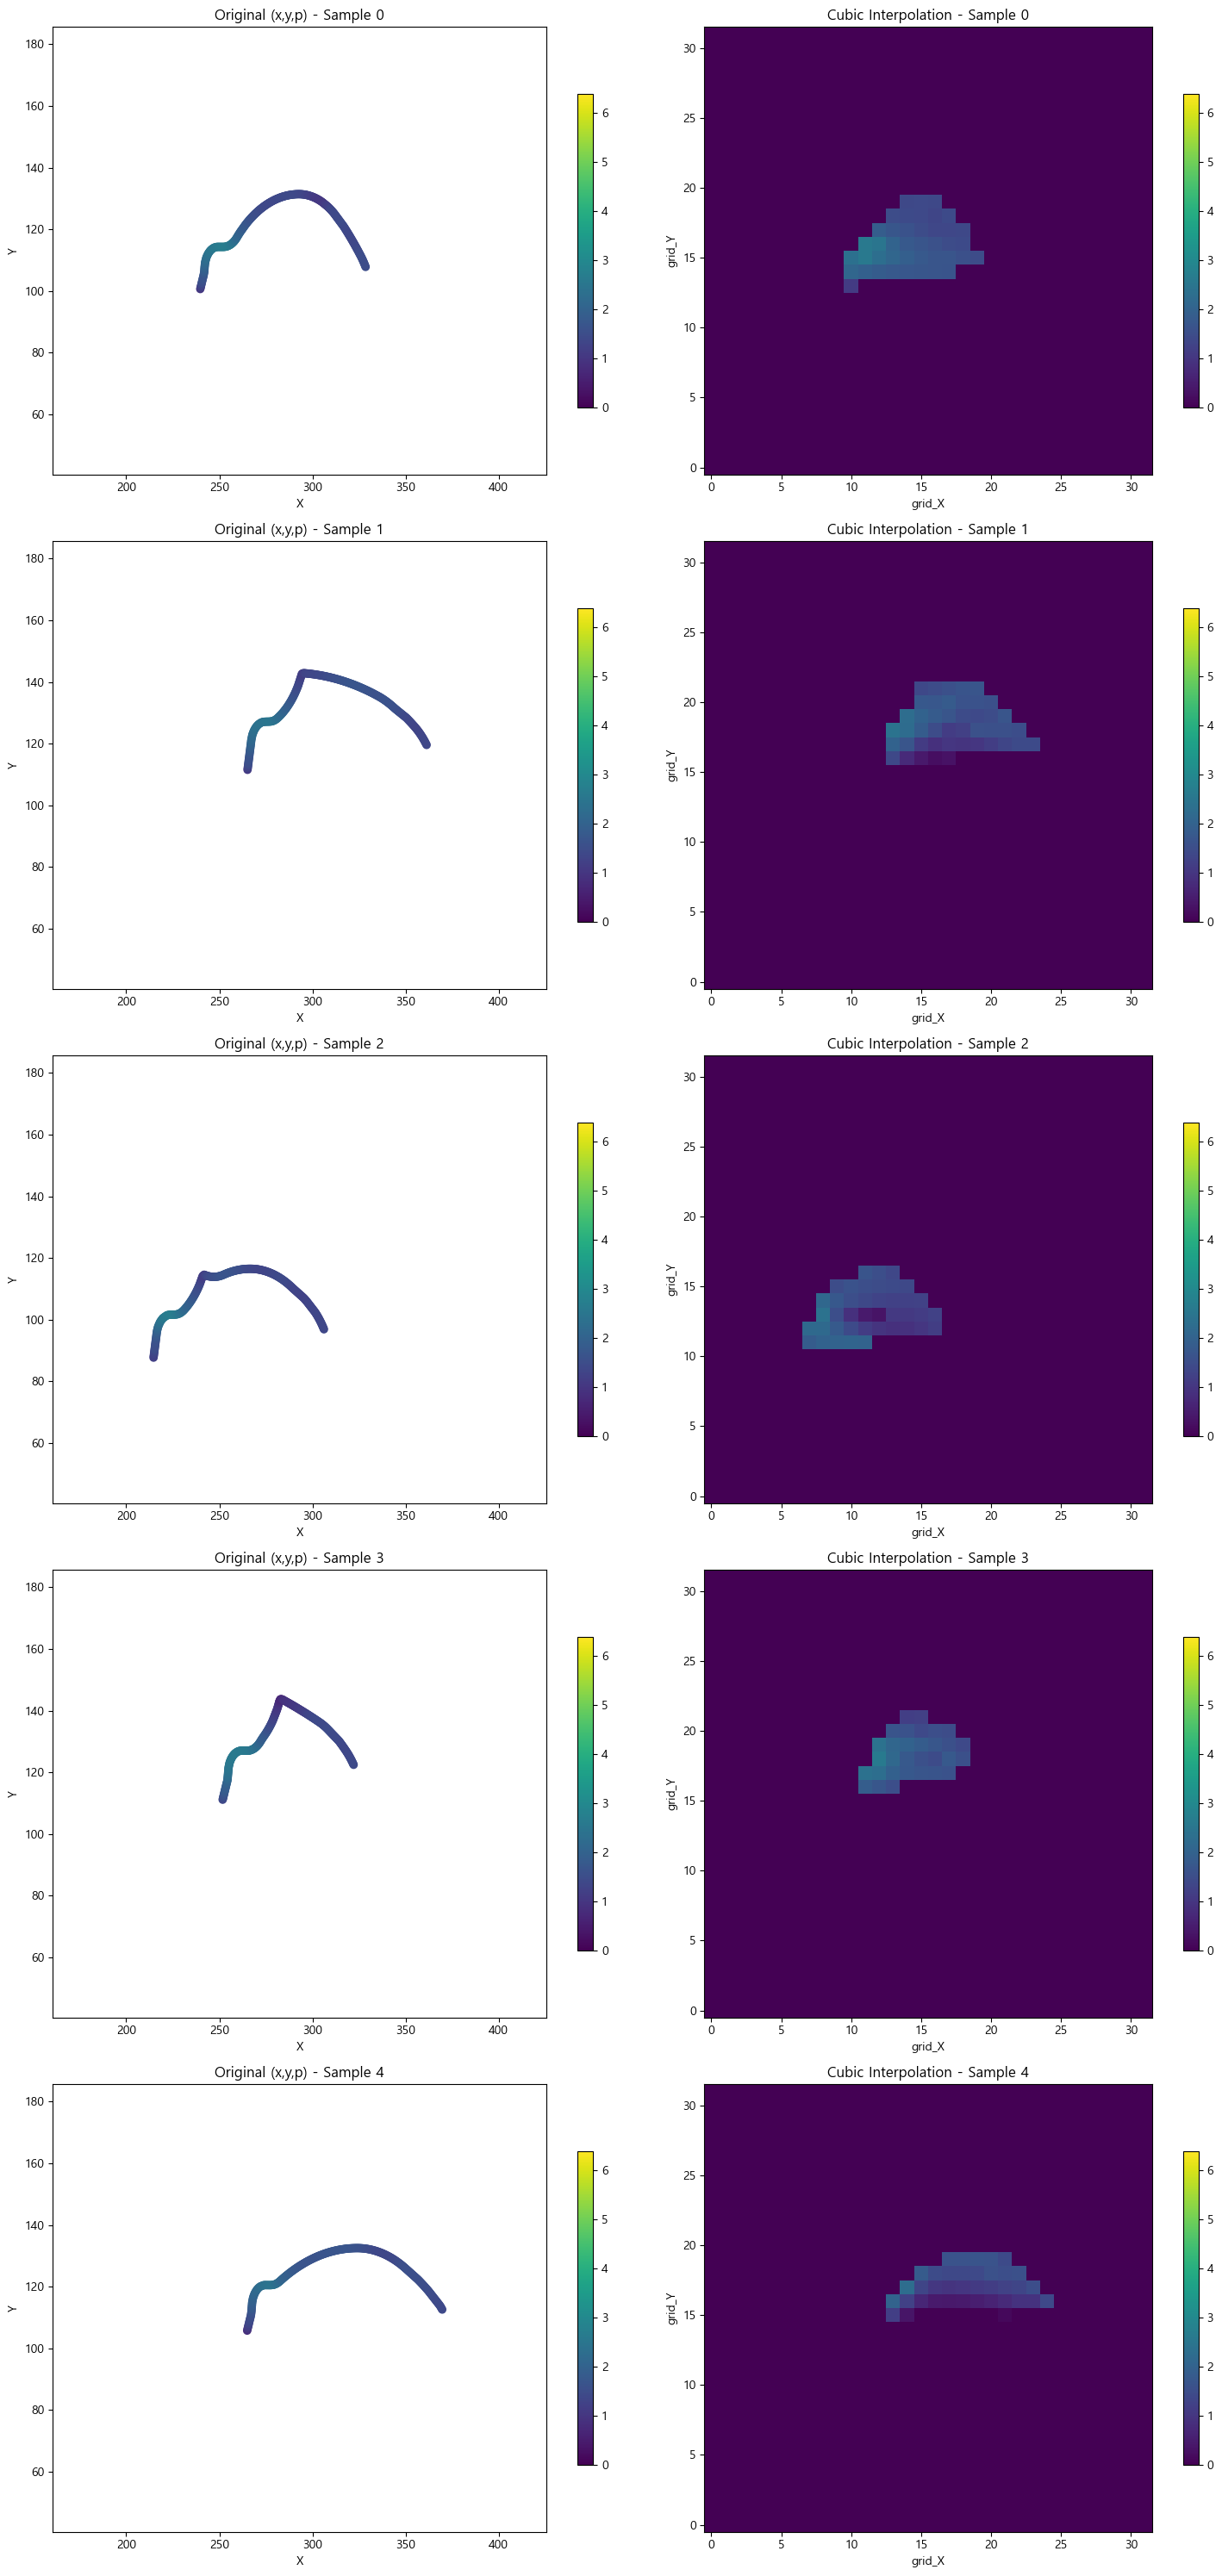

In [58]:
rasterizer = SpatialRasterizer(x_min, x_max, y_min, y_max, grid_size=32, interpolation_method='cubic')

# original (x,y,p), 3차 보간법을 사용한 그리드 생성 후 (x,y,p) 재구성 시각화 비교
n_rows = 5
n_cols = 2

vmin = float(train_val[p_cols].min().min())
vmax = float(train_val[p_cols].max().max())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 30))

for i in range(5):
    # original (x,y,p)
    sample_data = train_val.iloc[i]
    sc = axes[i, 0].scatter(
        sample_data[x_cols],
        sample_data[y_cols],
        c=sample_data[p_cols],
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )
    
    axes[i, 0].set_xlim(x_min, x_max)
    axes[i, 0].set_ylim(y_min, y_max)

    axes[i, 0].set_title(f"Original (x,y,p) - Sample {i}")
    axes[i, 0].set_xlabel("X")
    axes[i, 0].set_ylabel("Y")

    # 3차 보간법을 사용한 그리드 생성 후 (x,y,p) 재구성
    cubic_grid = rasterizer.rasterize_with_real_coordinates(train_val.iloc[i], method='cubic')
    axes[i, 1].imshow(cubic_grid,
                    cmap='viridis',
                    vmin=vmin,
                    vmax=vmax,
                    origin='lower'
                )

    axes[i, 1].set_title(f"Cubic Interpolation - Sample {i}")
    axes[i, 1].set_xlabel("grid_X")
    axes[i, 1].set_ylabel("grid_Y")

    # 컬러바 추가
    cbar1 = fig.colorbar(sc, ax=axes[i, 0], location="right", shrink=0.7)
    cbar2 = fig.colorbar(sc, ax=axes[i, 1], location="right", shrink=0.7)

fig.tight_layout()
plt.show()



재구성 (x,y,p) 2D-CNN feature extractor 학습

In [59]:
class MultiModalDataset(Dataset):
    def __init__(self, full_df, basic_features_np, rasterizer, labels_np=None):
        self.full_df = full_df.reset_index(drop=True)
        # 여기서 확실하게 NumPy로 바꿔주기
        if isinstance(basic_features_np, pd.DataFrame):
            basic_features_np = basic_features_np.to_numpy(dtype=np.float32)
        else:
            basic_features_np = np.array(basic_features_np, dtype=np.float32)

        self.basic_features_np = basic_features_np
        self.rasterizer = rasterizer
        self.labels_np = labels_np
        self.is_test = (labels_np is None)

    def __len__(self):
        return len(self.full_df)

    def __getitem__(self, idx):
        data_row = self.full_df.iloc[idx]
        image_grid = self.rasterizer.rasterize_with_real_coordinates(data_row)
        image_tensor = torch.from_numpy(image_grid).unsqueeze(0)  # (1, 64, 64)
        basic_feat_tensor = torch.from_numpy(self.basic_features_np[idx])

        if self.is_test:
            return image_tensor, basic_feat_tensor
        else:
            label_tensor = torch.tensor(self.labels_np[idx], dtype=torch.float32).view(1)
            return image_tensor, basic_feat_tensor, label_tensor


In [60]:
class ImageCNN(nn.Module):
    """개선된 ImageCNN: GAP 적용 + 파라미터 최적화"""
    def __init__(self, output_dim=64, input_size=32): 
        super(ImageCNN, self).__init__()
        
        # [구조 개선 1] 채널 수 최적화 (Overfitting 방지)
        self.features = nn.Sequential(
            # Block 1: 64x64 -> 32x32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 4: 8x8 -> 4x4 (채널 128 유지)
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        # [구조 개선 2] GAP (Global Average Pooling) 도입
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # GAP 이후 처리 (Dropout 강화)
        self.fc_out = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, output_dim), # 128 -> 64
            nn.ReLU(),
            nn.Dropout(0.4)
        )
    
    def forward(self, x):
        x = self.features(x)   # (Batch, 128, 4, 4)
        x = self.gap(x)        # (Batch, 128, 1, 1)
        return self.fc_out(x)  # (Batch, 64)


class FullE2EModel(nn.Module):
    """개선된 FullE2EModel: MLP 균형 조절 + GAP 적용"""
    def __init__(self, basic_feature_dim, image_cnn_output_dim=64, basic_mlp_output_dim=64, input_grid_size=32):
        super(FullE2EModel, self).__init__()
        
        # 1. Image Branch (개선된 CNN)
        self.image_cnn = ImageCNN(output_dim=image_cnn_output_dim, input_size=input_grid_size)
        
        # [구조 개선 3] Tabular Branch (MLP) 용량 확대
        self.basic_mlp = nn.Sequential(
            nn.Linear(basic_feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, basic_mlp_output_dim),
            nn.ReLU()
        )
        
        # 3. Fusion Head
        combined_dim = image_cnn_output_dim + basic_mlp_output_dim
        
        self.head = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    
    def forward(self, x_image, x_basic):
        img_feat = self.image_cnn(x_image)   # (Batch, 64)
        basic_feat = self.basic_mlp(x_basic) # (Batch, 64)
        combined = torch.cat((img_feat, basic_feat), dim=1) # (Batch, 128)
        output = self.head(combined)
        return output

In [61]:
print(train_X.head())

     Mass_Pilot_False  Mass_Pilot_True  Plant_Plant_1  Plant_Plant_2  \
395               1.0              0.0            0.0            1.0   
41                1.0              0.0            0.0            0.0   
108               1.0              0.0            0.0            0.0   
644               1.0              0.0            0.0            0.0   
56                0.0              1.0            0.0            1.0   

     Plant_Plant_3  Plant_Plant_4  Plant_Plant_6  Plant_Plant_7  \
395            0.0            0.0            0.0            0.0   
41             0.0            0.0            1.0            0.0   
108            0.0            1.0            0.0            0.0   
644            0.0            0.0            0.0            1.0   
56             0.0            0.0            0.0            0.0   

     Plant_Plant_8  Plant_Plant_9  ...         y90         y91         y92  \
395            0.0            0.0  ...  116.479718  116.941352  117.402986   
41      

In [64]:
#data split
train_X, val_X, train_Y, val_Y = train_test_split(train_X, train_Y, test_size=0.2, random_state=42)

train_dataset_cnn = MultiModalDataset(
    train_X,
    train_X.iloc[:,:-256*3],
    rasterizer,
    train_Y.values
)

train_loader_cnn = DataLoader(
    train_dataset_cnn,
    batch_size=32,
    shuffle=True
)

val_dataset_cnn = MultiModalDataset(
    val_X,
    val_X.iloc[:,:-256*3],
    rasterizer,
    val_Y.values
)

val_loader_cnn = DataLoader(
    val_dataset_cnn,
    batch_size=32,
    shuffle=False
)

# 실제 basic feature 차원 계산 (x, y, p 컬럼 제외)
basic_feature_dim_actual = train_X.iloc[:,:-256*3].shape[1]
print(f"실제 basic feature 차원: {basic_feature_dim_actual}")

cnn_extractor = FullE2EModel(
    basic_feature_dim=basic_feature_dim_actual,
    image_cnn_output_dim=64,
    basic_mlp_output_dim=64,
    input_grid_size=32
)

cnn_extractor = cnn_extractor.to(device)
optimizer = optim.Adam(cnn_extractor.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

best_val_loss = float('inf')
best_epoch = 0
train_losses = []
val_losses = []

print("\n[Main] CNN 피처 추출기 학습 시작 (Validation set으로 최적 epoch 결정)...")

for epoch in range(20):
    cnn_extractor.train()

    train_loss_sum = 0.0

    for img, basic, y in train_loader_cnn:
        img, basic, y = img.to(device), basic.to(device), y.to(device)

        optimizer.zero_grad()
        pred = cnn_extractor(img, basic)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()

    avg_train_loss = train_loss_sum / len(train_loader_cnn)
    train_losses.append(avg_train_loss)

    cnn_extractor.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for img, basic, y in val_loader_cnn:
            img, basic, y = img.to(device), basic.to(device), y.to(device)
            output = cnn_extractor(img, basic)
            loss = criterion(output, y)
            val_loss_sum += loss.item()

    avg_val_loss = val_loss_sum / len(val_loader_cnn)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(cnn_extractor.state_dict(), f'best_grid3232_model.pth')
    
    print(f"Epoch {epoch+1}/{20}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f} "
          f"{'⭐ Best' if epoch + 1 == best_epoch else ''}")

print(f"\n✅ CNN 피처 추출기 학습 완료.")
print(f"   - 최적 Epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")
print(f"   - 가중치 저장: best_grid3232_model.pth")
print(f"   - Train Loss 변화: {train_losses[0]:.4f} → {train_losses[-1]:.4f}")
print(f"   - Val Loss 변화: {val_losses[0]:.4f} → {val_losses[-1]:.4f}")
    
    


실제 basic feature 차원: 41

[Main] CNN 피처 추출기 학습 시작 (Validation set으로 최적 epoch 결정)...
Epoch 1/20, Train Loss: 0.6563, Val Loss: 0.7963 ⭐ Best
Epoch 2/20, Train Loss: 0.6540, Val Loss: 0.6782 ⭐ Best
Epoch 3/20, Train Loss: 0.6245, Val Loss: 0.5800 ⭐ Best
Epoch 4/20, Train Loss: 0.5838, Val Loss: 0.5820 
Epoch 5/20, Train Loss: 0.5818, Val Loss: 0.5320 ⭐ Best
Epoch 6/20, Train Loss: 0.5534, Val Loss: 0.4962 ⭐ Best
Epoch 7/20, Train Loss: 0.5501, Val Loss: 0.5269 
Epoch 8/20, Train Loss: 0.5334, Val Loss: 0.4465 ⭐ Best
Epoch 9/20, Train Loss: 0.5089, Val Loss: 0.4938 
Epoch 10/20, Train Loss: 0.5068, Val Loss: 0.4442 ⭐ Best
Epoch 11/20, Train Loss: 0.4970, Val Loss: 0.3501 ⭐ Best
Epoch 12/20, Train Loss: 0.4565, Val Loss: 0.5260 
Epoch 13/20, Train Loss: 0.4324, Val Loss: 0.3581 
Epoch 14/20, Train Loss: 0.4241, Val Loss: 0.3517 
Epoch 15/20, Train Loss: 0.4057, Val Loss: 0.3476 ⭐ Best
Epoch 16/20, Train Loss: 0.3654, Val Loss: 0.3755 
Epoch 17/20, Train Loss: 0.3384, Val Loss: 0.3553 
Epoch